# Slow Dynamics and High Variability in Networks with Clustered Connections




In [1]:
import numpy as np
from brian2 import *
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

from model import ClusterParams, ModelParams, NeuronNetwork, firing_rate

# Run and plot an un-clustered network

In [2]:
params = ModelParams()
cluster_params = ClusterParams(enabled=True, R_ee=1.0)

unclustered_network = NeuronNetwork(params, cluster_params)
unclustered_network.run()

In [3]:
def plot_spike_raster(spike_monitor_e, spike_monitor_i=None, n_e=0, title="Spike raster", ax=None):
    """Plot a spike raster for excitatory (and optionally inhibitory) neurons.
    
    Args:
        spike_monitor_e: Brian2 SpikeMonitor for excitatory neurons
        spike_monitor_i: Brian2 SpikeMonitor for inhibitory neurons (optional)
        n_e: Number of excitatory neurons (used to offset inhibitory neuron indices)
        title: Plot title
        ax: Matplotlib axes to plot on. If None, creates a new figure.
    
    Returns:
        The axes object
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 7))
    
    ax.plot(spike_monitor_e.t / ms, spike_monitor_e.i, ".", markersize=2, label="E")
    if spike_monitor_i is not None:
        ax.plot(
            spike_monitor_i.t / ms,
            spike_monitor_i.i + n_e,
            ".",
            markersize=2,
            label="I",
        )
    ax.set_ylabel("Neuron index")
    ax.set_title(title)
    ax.legend(loc="upper right")
    
    return ax


def plot_trial_rasters(network, n_trials=9, ncols=3, figsize=None, show_inhibitory=False):
    """Plot spike rasters for multiple trials of a network in a grid"""
    nrows = int(np.ceil(n_trials / ncols))
    
    if figsize is None:
        figsize = (4 * ncols, 3 * nrows)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True, sharey=True)
    axes = np.atleast_2d(axes)  # Ensure 2D array even if nrows=1
    
    for trial in range(n_trials):
        row = trial // ncols
        col = trial % ncols
        ax = axes[row, col]
        
        network.run()
        
        spike_monitor_i = network.spike_monitor_i if show_inhibitory else None
        n_e = network.params.N_E if show_inhibitory else 0
        
        plot_spike_raster(
            network.spike_monitor_e,
            spike_monitor_i,
            n_e=n_e,
            title=f"Trial {trial + 1}",
            ax=ax
        )
        
        # Only show legend on first plot to reduce clutter
        if trial > 0:
            ax.get_legend().remove()
    
    # Hide any unused subplots
    for idx in range(n_trials, nrows * ncols):
        row = idx // ncols
        col = idx % ncols
        axes[row, col].set_visible(False)
    
    plt.tight_layout()
    return fig, axes

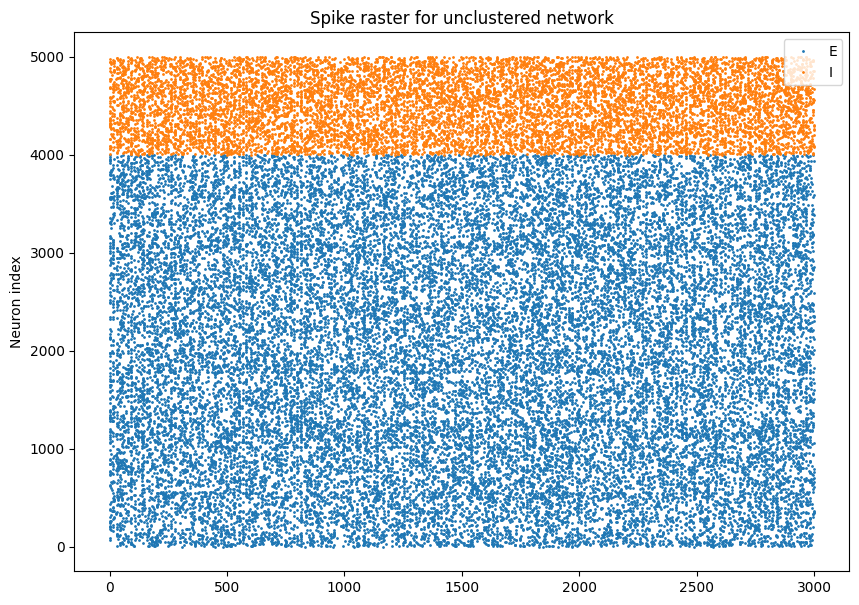

In [29]:
# Single raster plot
plot_spike_raster(
    unclustered_network.spike_monitor_e,
    unclustered_network.spike_monitor_i,
    n_e=params.N_E,
    title="Spike raster for unclustered network",
)
plt.show()

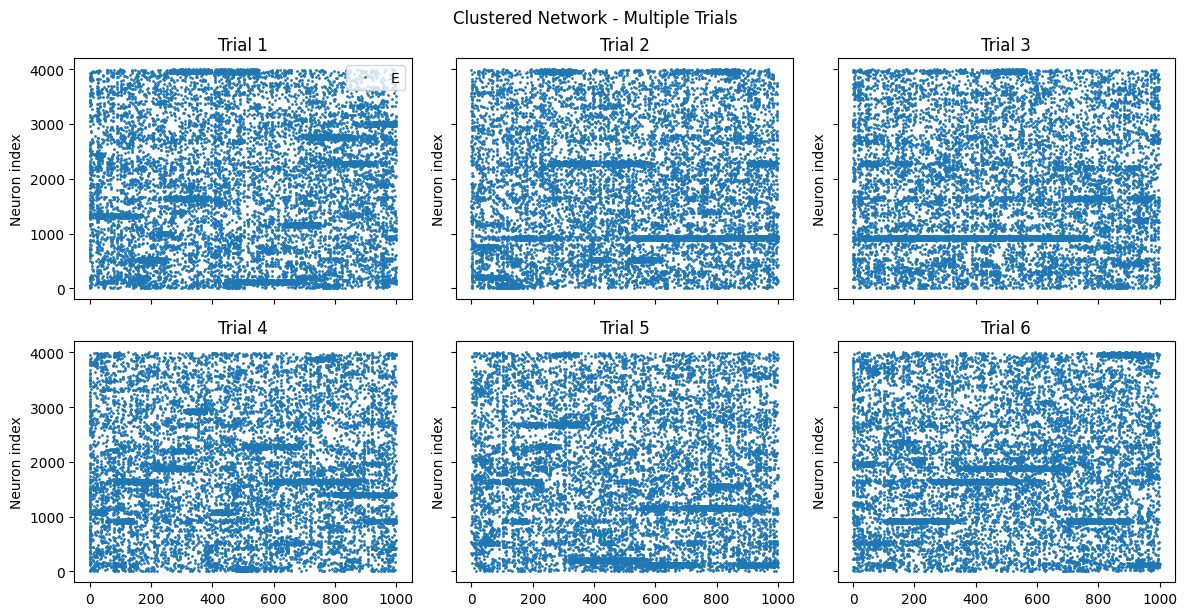

In [31]:
# Plot multiple trials in a grid
# Create a fresh network for the trial rasters
trial_network = NeuronNetwork(
    ModelParams(duration=1*second),  # Shorter duration for quick visualization
    ClusterParams(enabled=True, R_ee=2.3),
    seed=123
)

fig, axes = plot_trial_rasters(trial_network, n_trials=6, ncols=3, show_inhibitory=False)
fig.suptitle("Clustered Network - Multiple Trials", y=1.02)
plt.show()

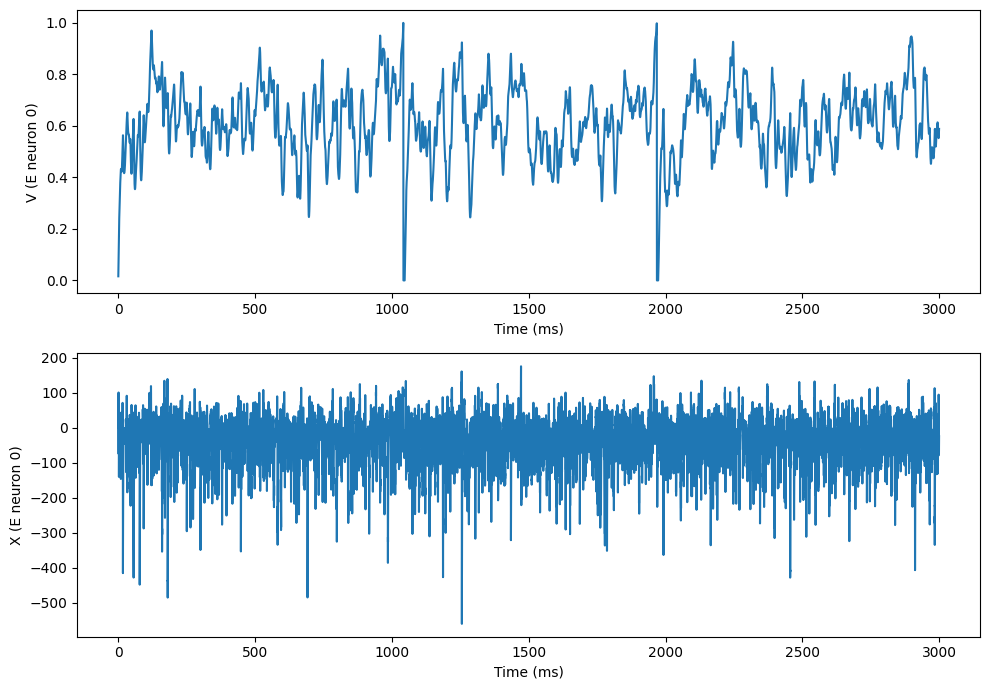

In [33]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7))

axes[0].plot(unclustered_network.state_monitor_e.t/ms, unclustered_network.state_monitor_e.V[0])
axes[0].set_ylabel('V (E neuron 0)')
axes[0].set_xlabel('Time (ms)')

axes[1].plot(unclustered_network.state_monitor_e.t/ms, unclustered_network.state_monitor_e.x[0])
axes[1].set_ylabel('X (E neuron 0)')
axes[1].set_xlabel('Time (ms)')

plt.tight_layout()

# Run and plot a clustered network

In [35]:
params = ModelParams()
cluster_params = ClusterParams(enabled=True, R_ee=2.3)

clustered_network = NeuronNetwork(params, cluster_params)
clustered_network.run()

<Axes: title={'center': 'Spike raster'}, ylabel='Neuron index'>

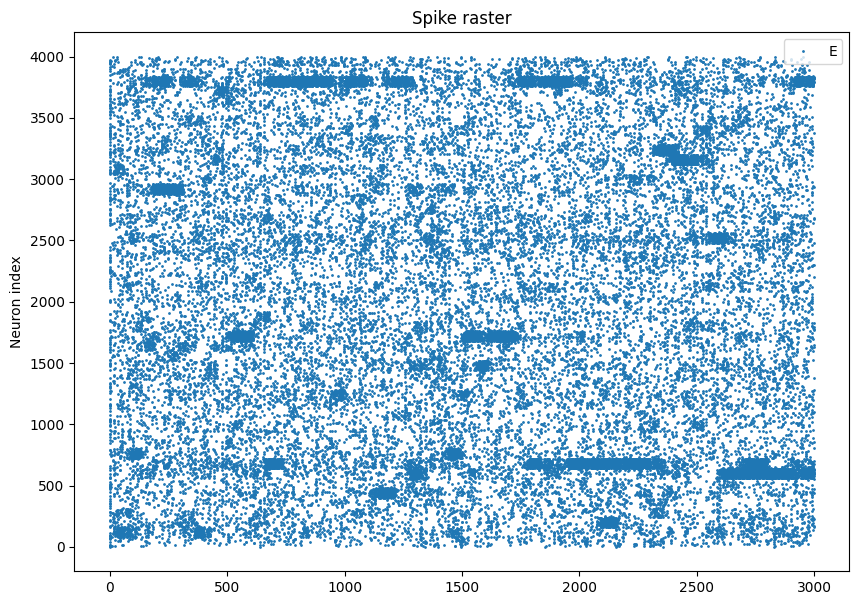

In [36]:
plot_spike_raster(clustered_network.spike_monitor_e)

## Plot the membrane potentials of a few neurons

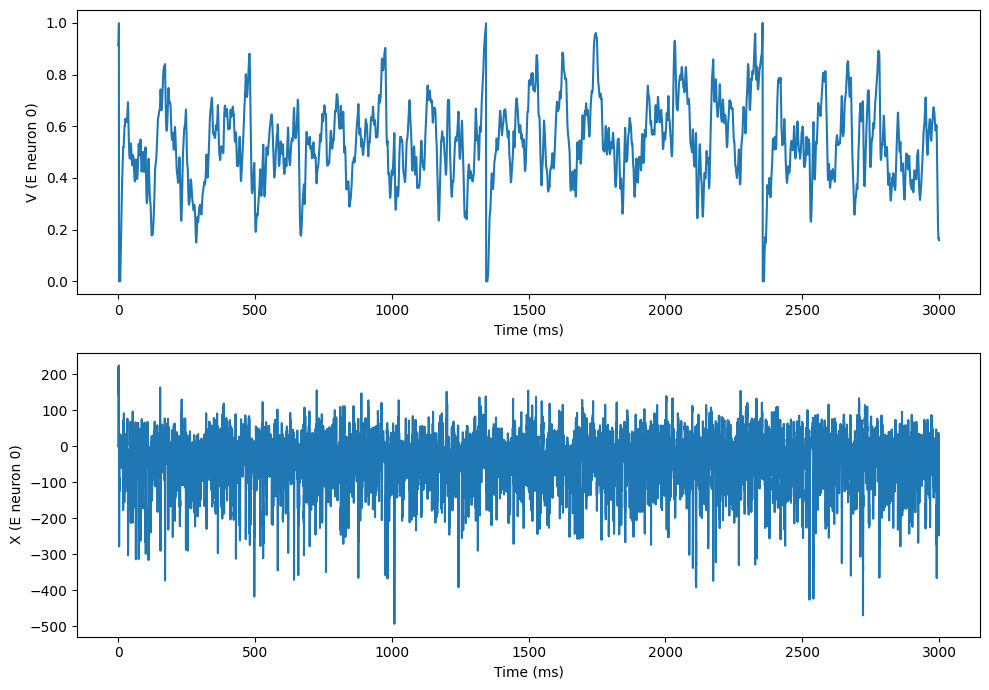

In [37]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7))

axes[0].plot(clustered_network.state_monitor_e.t/ms, clustered_network.state_monitor_e.V[0])
axes[0].set_ylabel('V (E neuron 0)')
axes[0].set_xlabel('Time (ms)')

axes[1].plot(clustered_network.state_monitor_e.t/ms, clustered_network.state_monitor_e.x[0])
axes[1].set_ylabel('X (E neuron 0)')
axes[1].set_xlabel('Time (ms)')

plt.tight_layout()
plt.show()

# Plotting the firing rate distribution

(4000,) (1000,)
(5000,)
(4000,) (1000,)
(5000,)


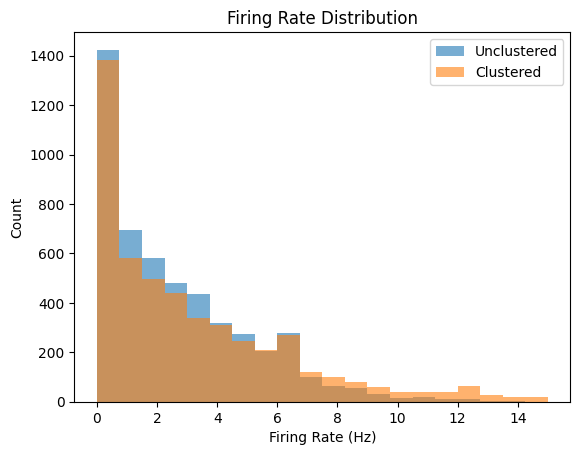

In [38]:
def plot_firing_rate_distribution(networks, labels, title, params):
    fig, ax = plt.subplots()

    firing_rates_by_label = {}
    for network, label in zip(networks, labels):
        firing_rates_e = firing_rate(
            network.spike_monitor_e,
            params.N_E,
            params.analysis_start_t,
            params.analysis_window_t,
        )
        firing_rates_i = firing_rate(
            network.spike_monitor_i,
            params.N_I,
            params.analysis_start_t,
            params.analysis_window_t,
        )
        print(firing_rates_e.shape, firing_rates_i.shape)

        rates = np.concatenate([firing_rates_e, firing_rates_i])
        print(rates.shape)

        firing_rates_by_label[label] = rates
        ax.hist(
            rates,
            bins=20,
            range=(0, 15),
            alpha=0.6,
            label=label,
        )

    ax.set_xlabel('Firing Rate (Hz)')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.legend()

    return firing_rates_by_label

firing_rates_by_label = plot_firing_rate_distribution(
    [unclustered_network, clustered_network],
    ["Unclustered", "Clustered"],
    title="Firing Rate Distribution",
    params=params,
)

# Checking difference of exponential filter to an ODE

In [ ]:
# TODO
# def x_prime(x, t1):
#     return -x / t1

# def g_prime(g, x, t2):
#     return (x - g) / t2

# def filter(t, t1, t2):
#     return 1 / (t2 - t1) * (np.exp(-t / t2) - np.exp(-t / t1))

# def euler_solve(x0, t, t1):
#     """Simple Euler method for x' = -x/t1."""
#     x = np.zeros_like(t)
#     x[0] = x0
#     dt = t[1] - t[0]
#     for i in range(1, len(t)):
#         x[i] = x[i - 1] + dt * x_prime(x[i - 1], t1)
#     return x

# t1 = 5.0
# x0 = 1.0
# t = np.linspace(0.0, 30.0, 600)

# x_num = euler_solve(x0, t, t1)

# sol = solve_ivp(
#     lambda tau, y: x_prime(y, t1),
#     t_span=(t[0], t[-1]),
#     y0=[x0],
#     t_eval=t,
# )
# x_scipy = sol.y[0]

# x_exact = x0 * np.exp(-t / t1)

# fig, ax = plt.subplots()
# ax.plot(t, x_num, label="Euler (numerical)")
# ax.plot(t, x_scipy, label="SciPy solve_ivp")
# ax.plot(t, x_exact, "--", label="Exact")
# ax.set_xlabel("t")
# ax.set_ylabel("x")
# ax.legend()
# plt.show()

# # Plot the filter for a sample t2.
# t2 = 2.0

# fig, ax = plt.subplots()
# ax.plot(t, filter(t, t1, t2), label="filter(t)")
# ax.set_xlabel("t")
# ax.set_ylabel("filter")
# ax.legend()
# plt.show()


    

# Experiment

Now instead of looking at a single network, we follow the paper's protocol of testing the uniform and clutered networks across 12 different network realizations, with 9 trials for each realization. This enables statistical analysis on spike counts.

In [14]:
def window_spikes_all_neurons(spike_times, spike_ids, n_neurons, window, step, timerange):
    """Compute spike counts in sliding windows for all neurons at once (vectorized)."""
    start_time = float(timerange[0])
    end_time = float(timerange[1])
    window = float(window)
    step = float(step)
    
    window_starts = np.arange(start_time, end_time - window + step, step)
    n_windows = len(window_starts)
    
    window_counts = np.zeros((n_neurons, n_windows), dtype=np.int32)
    spike_times = np.asarray(spike_times)
    spike_ids = np.asarray(spike_ids)
    
    for w, ws in enumerate(window_starts):
        mask = (spike_times >= ws) & (spike_times <= ws + window)
        window_counts[:, w] = np.bincount(spike_ids[mask], minlength=n_neurons)
    
    return window_counts


def calc_coeffs(cov_matrix, neuron_vars, params):
    """Calculates the correlation coefficients for all neuron pairs."""
    coeffs = []
    for i in range(params.N_E):
        for j in range(i+1, params.N_E):
            coeffs.append(cov_matrix[i][j] / np.sqrt(neuron_vars[i] * neuron_vars[j]))
    
    return np.array(coeffs)


def calc_cluster_coeffs(cov_matrix, neuron_vars, params, cluster_params):
    """Calculates correlation coefficients for same-cluster pairs only."""
    coeffs = []
    n_cluster = cluster_params.cluster_size
    for i in range(params.N_E):
        j_same_cluster = (i // n_cluster)*n_cluster + n_cluster
        for j in range(i+1, j_same_cluster):
            coeffs.append(cov_matrix[i][j] / np.sqrt(neuron_vars[i] * neuron_vars[j]))
    
    return np.array(coeffs)


class Experiment:
    def __init__(
        self,
        realizations=12,
        trials=9,
        model_params=ModelParams(),
        cluster_params=ClusterParams(enabled=True, R_ee=2.5),
        seed=42,
        corr_window=50*ms,
        corr_step=25*ms,
    ):
        self.realizations = realizations
        self.trials = trials
        self.model_params = model_params
        self.cluster_params = cluster_params
        self.seed = seed
        
        # Correlation analysis parameters
        self.corr_window = corr_window
        self.corr_step = corr_step
        
        # Initialize networks
        self.uniform_networks = self._initialize_networks(
            realizations, model_params, ClusterParams(enabled=True, R_ee=1.0), "uniform"
        )
        self.clustered_networks = self._initialize_networks(
            realizations, model_params, cluster_params, "clustered"
        )
        
        # Fano factor spike counts: (realizations, trials, N_E)
        counts_shape = (realizations, trials, model_params.N_E)
        self.uniform_spike_counts = np.zeros(counts_shape, dtype=np.int32)
        self.clustered_spike_counts = np.zeros(counts_shape, dtype=np.int32)
        
        # Firing rates: (realizations, trials, N_E + N_I)
        n_total = model_params.N_E + model_params.N_I
        rates_shape = (realizations, trials, n_total)
        self.uniform_firing_rates = np.zeros(rates_shape, dtype=np.float64)
        self.clustered_firing_rates = np.zeros(rates_shape, dtype=np.float64)
        
        # Correlation accumulators: accumulate covariance/variance across all trials
        # We compute running sums and divide at the end to get means
        n_e = model_params.N_E
        self.uniform_cov_sum = np.zeros((n_e, n_e), dtype=np.float64)
        self.uniform_var_sum = np.zeros(n_e, dtype=np.float64)
        self.clustered_cov_sum = np.zeros((n_e, n_e), dtype=np.float64)
        self.clustered_var_sum = np.zeros(n_e, dtype=np.float64)

    def _initialize_networks(self, realizations, model_params, cluster_params, name):
        networks = []
        for r in range(realizations):
            network = NeuronNetwork(model_params, cluster_params, seed=self.seed + 1000 * r)
            print(f"Built {name} network {r + 1}/{realizations}")
            networks.append(network)
        return networks

    def run(self):
        print("Running uniform networks...")
        self._run_networks(
            self.uniform_networks, 
            self.uniform_spike_counts,
            self.uniform_firing_rates,
            self.uniform_cov_sum,
            self.uniform_var_sum
        )
        print("Running clustered networks...")
        self._run_networks(
            self.clustered_networks, 
            self.clustered_spike_counts,
            self.clustered_firing_rates,
            self.clustered_cov_sum,
            self.clustered_var_sum
        )
        print("Done.")

    def _run_networks(self, networks, spike_counts, firing_rates_arr, cov_sum, var_sum):
        params = self.model_params
        start_t = params.analysis_start_t
        
        # Different windows for different analyses
        corr_end_t = start_t + params.analysis_window_t
        fano_end_t = start_t + params.fano_factor_window_t
        firing_rate_end_t = start_t + params.firing_rate_window_t
        
        corr_timerange = (start_t, corr_end_t)

        for r, network in enumerate(networks):
            for t in range(self.trials):
                network.run()
                
                spike_times_e = network.spike_monitor_e.t
                spike_ids_e = network.spike_monitor_e.i
                spike_times_i = network.spike_monitor_i.t
                spike_ids_i = network.spike_monitor_i.i
                
                # Fano factor: count spikes in the fano_factor_window
                fano_mask = (spike_times_e >= start_t) & (spike_times_e < fano_end_t)
                spike_counts[r, t, :] = np.bincount(
                    spike_ids_e[fano_mask], minlength=params.N_E
                )
                
                # Firing rates: count spikes in firing_rate_window for E and I neurons
                mask_e = (spike_times_e >= start_t) & (spike_times_e <= firing_rate_end_t)
                mask_i = (spike_times_i >= start_t) & (spike_times_i <= firing_rate_end_t)
                
                counts_e = np.bincount(spike_ids_e[mask_e], minlength=params.N_E)
                counts_i = np.bincount(spike_ids_i[mask_i], minlength=params.N_I)
                
                # Convert to rates (Hz)
                firing_rate_duration = float(params.firing_rate_window_t)
                firing_rates_arr[r, t, :params.N_E] = counts_e / firing_rate_duration
                firing_rates_arr[r, t, params.N_E:] = counts_i / firing_rate_duration
                
                # Correlation: compute window counts and accumulate cov/var
                window_counts = window_spikes_all_neurons(
                    spike_times_e, spike_ids_e, params.N_E,
                    self.corr_window, self.corr_step, corr_timerange
                )
                cov_matrix = np.cov(window_counts, rowvar=True, bias=False)
                row_vars = np.var(window_counts, axis=1, ddof=1)
                
                cov_sum += cov_matrix
                var_sum += row_vars
                
                print(f"  Realization {r + 1}/{len(networks)}, Trial {t + 1}/{self.trials}")

    def _compute_fano_factor(self, spike_counts):
        mean = spike_counts.mean(axis=1)
        var = spike_counts.var(axis=1, ddof=1)
        with np.errstate(divide="ignore", invalid="ignore"):
            return np.where(mean > 0, var / mean, np.nan)

    def fano_factor(self):
        return (
            self._compute_fano_factor(self.uniform_spike_counts),
            self._compute_fano_factor(self.clustered_spike_counts),
        )

    def get_firing_rates(self, population='all'):
        """Get firing rates across all trials.
        
        Args:
            population: 'all', 'excitatory', or 'inhibitory'
        
        Returns:
            (uniform_rates, clustered_rates): Flattened arrays of firing rates
        """
        params = self.model_params
        
        if population == 'excitatory':
            uniform = self.uniform_firing_rates[:, :, :params.N_E].ravel()
            clustered = self.clustered_firing_rates[:, :, :params.N_E].ravel()
        elif population == 'inhibitory':
            uniform = self.uniform_firing_rates[:, :, params.N_E:].ravel()
            clustered = self.clustered_firing_rates[:, :, params.N_E:].ravel()
        else:  # 'all'
            uniform = self.uniform_firing_rates.ravel()
            clustered = self.clustered_firing_rates.ravel()
        
        return uniform, clustered

    def mean_cov_var(self):
        """Get mean covariance matrices and variances from accumulated sums."""
        total_trials = self.realizations * self.trials
        return (
            self.uniform_cov_sum / total_trials,
            self.uniform_var_sum / total_trials,
            self.clustered_cov_sum / total_trials,
            self.clustered_var_sum / total_trials,
        )

    def correlation_coefficients(self, same_cluster_only=False):
        """Compute correlation coefficients from accumulated statistics.
        
        Args:
            same_cluster_only: If True, only compute correlations for neuron pairs
                              within the same cluster.
        
        Returns:
            (uniform_coeffs, clustered_coeffs): Arrays of correlation coefficients
        """
        uniform_cov, uniform_var, clustered_cov, clustered_var = self.mean_cov_var()
        
        if same_cluster_only:
            uniform_coeffs = calc_cluster_coeffs(uniform_cov, uniform_var, self.model_params, self.cluster_params)
            clustered_coeffs = calc_cluster_coeffs(clustered_cov, clustered_var, self.model_params, self.cluster_params)
        else:
            uniform_coeffs = calc_coeffs(uniform_cov, uniform_var, self.model_params)
            clustered_coeffs = calc_coeffs(clustered_cov, clustered_var, self.model_params)
        
        return uniform_coeffs, clustered_coeffs
    
    def plot_firing_rate_distribution(self, population='all', bins=20, rate_range=(0, 15)):
        """Plot firing rate distribution comparing uniform vs clustered networks.
        
        Args:
            population: 'all', 'excitatory', or 'inhibitory'
            bins: Number of histogram bins
            rate_range: Tuple of (min_rate, max_rate) for histogram range
        
        Returns:
            fig, ax: Matplotlib figure and axes
        """
        uniform_rates, clustered_rates = self.get_firing_rates(population)
        
        fig, ax = plt.subplots(figsize=(8, 5))
        
        ax.hist(uniform_rates, bins=bins, range=rate_range, alpha=0.6, 
                label=f'Uniform (mean={np.mean(uniform_rates):.2f} Hz)')
        ax.hist(clustered_rates, bins=bins, range=rate_range, alpha=0.6,
                label=f'Clustered (mean={np.mean(clustered_rates):.2f} Hz)')
        
        ax.set_xlabel('Firing Rate (Hz)')
        ax.set_ylabel('Count')
        
        title_pop = population.capitalize() if population != 'all' else 'All'
        ax.set_title(f'Firing Rate Distribution ({title_pop} Neurons)\n'
                     f'{self.realizations} realizations × {self.trials} trials')
        ax.legend()
        
        return fig, ax

In [ ]:
# Run experiment with fewer realizations/trials for testing
e = Experiment(
    realizations=1, 
    trials=9, 
    model_params=ModelParams(duration=3*second),
    cluster_params=ClusterParams(enabled=True, R_ee=2.3),
)
e.run()

Built uniform network 1/1
Built clustered network 1/1
Running uniform networks...
  Realization 1/1, Trial 1/9
  Realization 1/1, Trial 2/9
  Realization 1/1, Trial 3/9
  Realization 1/1, Trial 4/9
  Realization 1/1, Trial 5/9
  Realization 1/1, Trial 6/9
  Realization 1/1, Trial 7/9
  Realization 1/1, Trial 8/9
  Realization 1/1, Trial 9/9
Running clustered networks...
  Realization 1/1, Trial 1/9
  Realization 1/1, Trial 2/9
  Realization 1/1, Trial 3/9


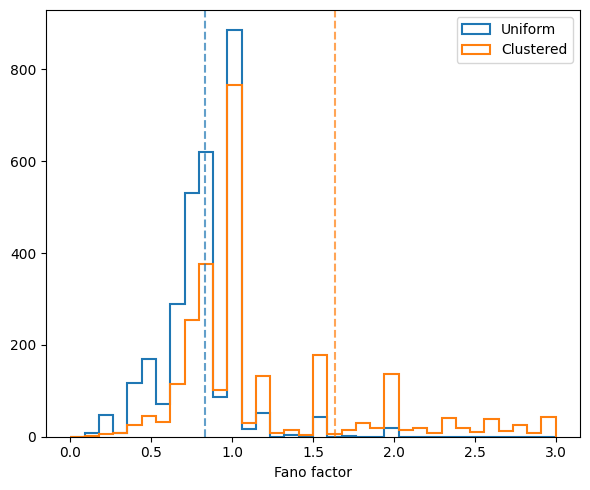

Mean Fano Factor (Uniform): 0.831
Mean Fano Factor (Clustered): 1.635


In [6]:
# Plot Fano factor distribution
uniform_ff, clustered_ff = e.fano_factor()

fig, ax = plt.subplots(figsize=(6, 5))

bins = np.linspace(0, 3, 35)
ax.hist(uniform_ff.ravel(), bins=bins, histtype='step', linewidth=1.5, label='Uniform')
ax.hist(clustered_ff.ravel(), bins=bins, histtype='step', linewidth=1.5, label='Clustered')

uniform_mean = np.nanmean(uniform_ff)
clustered_mean = np.nanmean(clustered_ff)
ax.axvline(uniform_mean, color='C0', alpha=0.7, linestyle='--')
ax.axvline(clustered_mean, color='C1', alpha=0.7, linestyle='--')

ax.set_xlabel('Fano factor')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean Fano Factor (Uniform): {uniform_mean:.3f}")
print(f"Mean Fano Factor (Clustered): {clustered_mean:.3f}")

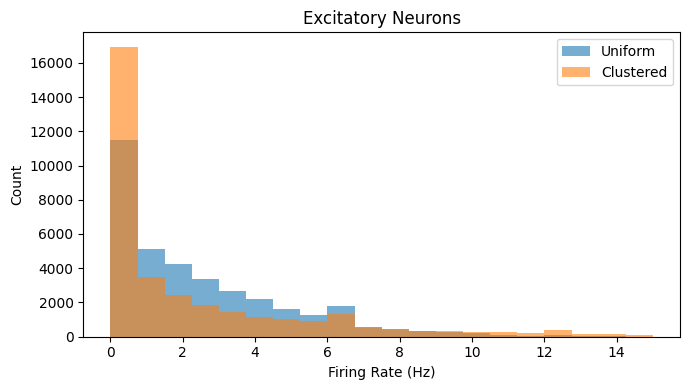

In [12]:
# Can also plot just excitatory or inhibitory neurons
fig, axes = plt.subplots(1, 1, figsize=(7, 4))

uniform_e, clustered_e = e.get_firing_rates('excitatory')
axes.hist(uniform_e, bins=20, range=(0, 15), alpha=0.6, label='Uniform')
axes.hist(clustered_e, bins=20, range=(0, 15), alpha=0.6, label='Clustered')
axes.set_xlabel('Firing Rate (Hz)')
axes.set_ylabel('Count')
axes.set_title('Excitatory Neurons')
axes.legend()

plt.tight_layout()
plt.show()

WARNING    /var/folders/_f/t5z2mynd5cg523nhd8bwyj980000gn/T/ipykernel_78866/2157619493.py:27: RuntimeWarning: invalid value encountered in scalar divide
  coeffs.append(cov_matrix[i][j] / np.sqrt(neuron_vars[i] * neuron_vars[j]))
 [py.warnings]
WARNING    /var/folders/_f/t5z2mynd5cg523nhd8bwyj980000gn/T/ipykernel_78866/2157619493.py:39: RuntimeWarning: invalid value encountered in scalar divide
  coeffs.append(cov_matrix[i][j] / np.sqrt(neuron_vars[i] * neuron_vars[j]))
 [py.warnings]


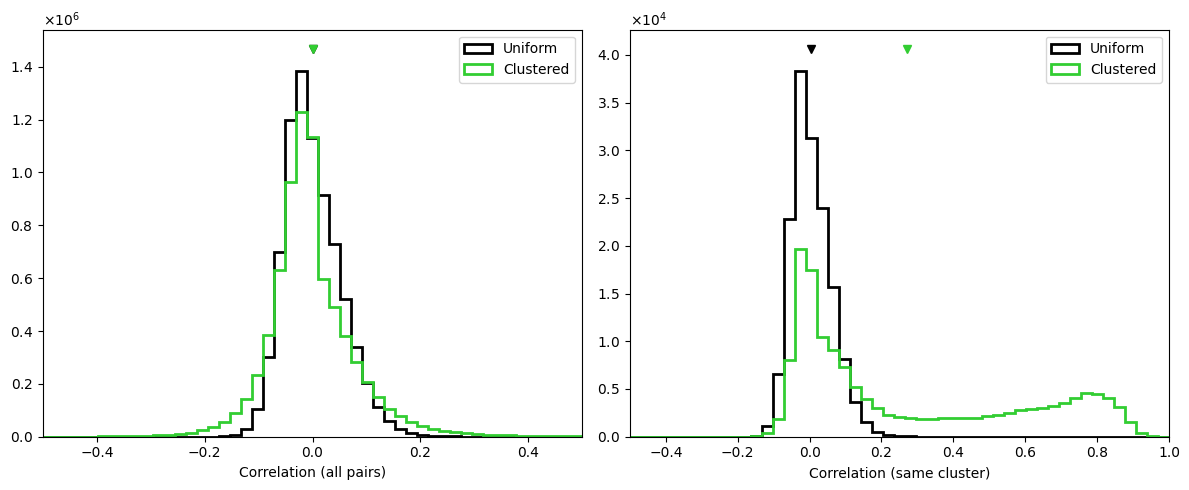

Mean correlation (all pairs) - Uniform: 0.0005, Clustered: 0.0013
Mean correlation (same cluster) - Uniform: 0.0050, Clustered: 0.2700


In [13]:
# Plot correlation coefficient distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# All pairs
uniform_coeffs, clustered_coeffs = e.correlation_coefficients(same_cluster_only=False)

bins_all = np.linspace(-0.5, 0.5, 50)
axes[0].hist(uniform_coeffs, bins=bins_all, histtype='step', linewidth=2, color='black', label='Uniform')
axes[0].hist(clustered_coeffs, bins=bins_all, histtype='step', linewidth=2, color='limegreen', label='Clustered')
axes[0].set_xlabel('Correlation (all pairs)')
axes[0].set_xlim(-0.5, 0.5)
axes[0].legend()

# Scientific notation on y-axis
fmt0 = ScalarFormatter(useMathText=True)
fmt0.set_powerlimits((6, 6))
axes[0].yaxis.set_major_formatter(fmt0)

# Mean markers (triangles at top)
y_top0 = axes[0].get_ylim()[1]
axes[0].plot([np.nanmean(uniform_coeffs)], [y_top0 * 1.01], marker='v', markersize=6, color='black', clip_on=False)
axes[0].plot([np.nanmean(clustered_coeffs)], [y_top0 * 1.01], marker='v', markersize=6, color='limegreen', clip_on=False)

# Same cluster pairs only
uniform_cluster_coeffs, clustered_cluster_coeffs = e.correlation_coefficients(same_cluster_only=True)

bins_cluster = np.linspace(-0.5, 1.0, 50)
axes[1].hist(uniform_cluster_coeffs, bins=bins_cluster, histtype='step', linewidth=2, color='black', label='Uniform')
axes[1].hist(clustered_cluster_coeffs, bins=bins_cluster, histtype='step', linewidth=2, color='limegreen', label='Clustered')
axes[1].set_xlabel('Correlation (same cluster)')
axes[1].set_xlim(-0.5, 1.0)
axes[1].legend()

# Scientific notation on y-axis
fmt1 = ScalarFormatter(useMathText=True)
fmt1.set_powerlimits((4, 4))
axes[1].yaxis.set_major_formatter(fmt1)

# Mean markers (triangles at top)
y_top1 = axes[1].get_ylim()[1]
axes[1].plot([np.nanmean(uniform_cluster_coeffs)], [y_top1 * 1.01], marker='v', markersize=6, color='black', clip_on=False)
axes[1].plot([np.nanmean(clustered_cluster_coeffs)], [y_top1 * 1.01], marker='v', markersize=6, color='limegreen', clip_on=False)

plt.tight_layout()
plt.show()

print(f"Mean correlation (all pairs) - Uniform: {np.nanmean(uniform_coeffs):.4f}, Clustered: {np.nanmean(clustered_coeffs):.4f}")
print(f"Mean correlation (same cluster) - Uniform: {np.nanmean(uniform_cluster_coeffs):.4f}, Clustered: {np.nanmean(clustered_cluster_coeffs):.4f}")